# INDILEX Dataset Length Audit

This notebook audits batch-wise CSV datasets before designing a long-document annotation/chunking strategy.

It reports:
- file and row counts
- missing/empty judgments
- duplicate `case_id`
- exact duplicate normalized judgments
- character and word-length distributions
- tokenizer-based token counts when enabled
- length buckets
- direct-vs-chunk routing estimates
- case-type and language distributions
- annotation completeness
- per-file and per-case-type summaries
- CSV reports for further analysis

**Normal usage:** change only `INPUT_PATH` and `OUTPUT_DIR` in the configuration cell.


In [1]:
# Optional: run once if needed
!pip install -q pandas numpy tqdm transformers matplotlib openpyxl


    torch (>=1.7.*)
           ~~~~~~^


In [2]:
from pathlib import Path
import hashlib
import json
import re
import warnings

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)


/mnt/Data/yashv7523/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/mnt/Data/yashv7523/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
# ============================================================
# USER CONFIGURATION — normally change only these two paths
# ============================================================

# Can be:
# 1) one CSV file, OR
# 2) a directory containing CSV files (searched recursively)
INPUT_PATH = "final_merged_hindi_cleaned.csv"

OUTPUT_DIR = "audit_reports"

# Main judgment column
TEXT_COLUMN = "judgment_text"

# Expected annotation columns
ANNOTATION_COLUMNS = [
    "subject",
    "object",
    "objective_aspect",
    "subjective_aspect",
    "legal_provision",
    "reasoning",
]

# Token counting:
# True = use the actual tokenizer below (recommended before choosing chunk sizes)
# False = skip tokenizer counting and use character/word statistics only
USE_TOKENIZER = True

# Use the tokenizer of the model you plan to use for annotation.
TOKENIZER_NAME = "Qwen/Qwen2.5-14B-Instruct"

# Routing thresholds for AUDIT ONLY.
# These do not modify or chunk the dataset.
DIRECT_SAFE_TOKEN_LIMIT = 7000
LONG_TOKEN_LIMIT = 16000
VERY_LONG_TOKEN_LIMIT = 32000

# Optional: limit rows during a quick test. None = audit all rows.
MAX_ROWS_PER_FILE = None

OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration loaded")
print("INPUT_PATH :", INPUT_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("USE_TOKENIZER:", USE_TOKENIZER)
print("TOKENIZER_NAME:", TOKENIZER_NAME if USE_TOKENIZER else "disabled")


Configuration loaded
INPUT_PATH : final_merged_hindi_cleaned.csv
OUTPUT_DIR: audit_reports
USE_TOKENIZER: True
TOKENIZER_NAME: Qwen/Qwen2.5-14B-Instruct


In [5]:
# ============================================================
# HELPERS
# ============================================================

MISSING_STRINGS = {"", "nan", "none", "null", "na", "n/a"}

def is_missing(value):
    if value is None:
        return True
    try:
        if pd.isna(value):
            return True
    except Exception:
        pass
    return str(value).strip().lower() in MISSING_STRINGS

def normalize_for_duplicate_check(text):
    if is_missing(text):
        return ""
    text = str(text)
    text = text.replace("\u00a0", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def text_hash(text):
    norm = normalize_for_duplicate_check(text)
    if not norm:
        return ""
    return hashlib.sha256(norm.encode("utf-8", errors="ignore")).hexdigest()

def safe_read_csv(path):
    encodings = ["utf-8-sig", "utf-8", "cp1252", "latin1"]
    last_error = None
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False), enc
        except Exception as e:
            last_error = e
    raise RuntimeError(f"Could not read {path}. Last error: {last_error}")

def discover_csv_files(input_path):
    p = Path(input_path)
    if p.is_file():
        if p.suffix.lower() != ".csv":
            raise ValueError(f"Input file is not CSV: {p}")
        return [p]
    if p.is_dir():
        files = sorted(p.rglob("*.csv"))
        if not files:
            raise FileNotFoundError(f"No CSV files found under: {p}")
        return files
    raise FileNotFoundError(f"INPUT_PATH does not exist: {p}")

def annotation_state(row):
    flags = [is_missing(row.get(c, "")) for c in ANNOTATION_COLUMNS]
    if all(flags):
        return "all_missing"
    if not any(flags):
        return "complete"
    return "partial"

def classify_length_bucket(tokens):
    if pd.isna(tokens):
        return "token_count_unavailable"
    tokens = int(tokens)
    if tokens <= 4000:
        return "0-4K"
    if tokens <= 8000:
        return "4K-8K"
    if tokens <= 16000:
        return "8K-16K"
    if tokens <= 32000:
        return "16K-32K"
    return "32K+"

def routing_decision(tokens):
    if pd.isna(tokens):
        return "unknown"
    tokens = int(tokens)
    return "direct" if tokens <= DIRECT_SAFE_TOKEN_LIMIT else "chunk_candidate"


In [6]:
# ============================================================
# DISCOVER FILES
# ============================================================

csv_files = discover_csv_files(INPUT_PATH)
print(f"Found {len(csv_files)} CSV file(s).")
for p in csv_files[:10]:
    print(" -", p)
if len(csv_files) > 10:
    print(f" ... and {len(csv_files)-10} more")


Found 1 CSV file(s).
 - final_merged_hindi_cleaned.csv


In [7]:
# ============================================================
# LOAD AND COMBINE DATASETS SAFELY
# ============================================================

frames = []
load_errors = []

for file_path in tqdm(csv_files, desc="Loading CSV files"):
    try:
        df, encoding = safe_read_csv(file_path)
        if MAX_ROWS_PER_FILE is not None:
            df = df.head(MAX_ROWS_PER_FILE).copy()

        if TEXT_COLUMN not in df.columns:
            load_errors.append({
                "file": str(file_path),
                "error": f"Missing required text column: {TEXT_COLUMN}"
            })
            continue

        for col in ANNOTATION_COLUMNS:
            if col not in df.columns:
                df[col] = ""

        df["_source_file"] = file_path.name
        df["_source_path"] = str(file_path)
        df["_source_row"] = np.arange(len(df))
        df["_encoding_used"] = encoding
        frames.append(df)

    except Exception as e:
        load_errors.append({"file": str(file_path), "error": repr(e)})

if not frames:
    raise RuntimeError("No valid CSV data could be loaded.")

data = pd.concat(frames, ignore_index=True)
print(f"Loaded {len(data):,} rows from {len(frames)} file(s).")

if load_errors:
    print(f"WARNING: {len(load_errors)} file(s) had load/schema errors.")
    display(pd.DataFrame(load_errors).head(20))


Loading CSV files:   0%|          | 0/1 [00:00<?, ?it/s]

Loaded 742 rows from 1 file(s).


In [8]:
# ============================================================
# BASIC TEXT METRICS AND DATA QUALITY FLAGS
# ============================================================

data["_is_empty_judgment"] = data[TEXT_COLUMN].apply(is_missing)
data["_normalized_text"] = data[TEXT_COLUMN].apply(normalize_for_duplicate_check)
data["_text_hash"] = data[TEXT_COLUMN].apply(text_hash)

data["char_count"] = data[TEXT_COLUMN].apply(
    lambda x: 0 if is_missing(x) else len(str(x))
)
data["word_count"] = data[TEXT_COLUMN].apply(
    lambda x: 0 if is_missing(x) else len(str(x).split())
)
data["annotation_state"] = data.apply(annotation_state, axis=1)

if "case_id" in data.columns:
    valid_case_ids = data["case_id"].apply(lambda x: "" if is_missing(x) else str(x).strip())
    data["_case_id_clean"] = valid_case_ids
    data["_duplicate_case_id"] = (
        data["_case_id_clean"].ne("") &
        data["_case_id_clean"].duplicated(keep=False)
    )
else:
    data["_case_id_clean"] = ""
    data["_duplicate_case_id"] = False

data["_duplicate_judgment"] = (
    data["_text_hash"].ne("") &
    data["_text_hash"].duplicated(keep=False)
)

print("Basic metrics created.")


Basic metrics created.


In [9]:
# ============================================================
# OPTIONAL TOKENIZER-BASED TOKEN COUNTING
# ============================================================

data["token_count"] = np.nan

if USE_TOKENIZER:
    from transformers import AutoTokenizer

    print(f"Loading tokenizer: {TOKENIZER_NAME}")
    tokenizer = AutoTokenizer.from_pretrained(
        TOKENIZER_NAME,
        trust_remote_code=True
    )

    def count_tokens(text):
        if is_missing(text):
            return 0
        # No truncation: audit must measure the real full length.
        return len(tokenizer.encode(str(text), add_special_tokens=False))

    tqdm.pandas(desc="Counting tokens")
    data["token_count"] = data[TEXT_COLUMN].progress_apply(count_tokens)
    print("Token counting complete.")
else:
    print("Tokenizer counting skipped. Set USE_TOKENIZER=True for model-specific counts.")


Loading tokenizer: Qwen/Qwen2.5-14B-Instruct


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Counting tokens:   0%|          | 0/742 [00:00<?, ?it/s]

Token counting complete.


In [10]:
# ============================================================
# LENGTH BUCKETS AND ROUTING ESTIMATE
# ============================================================

if USE_TOKENIZER:
    data["length_bucket"] = data["token_count"].apply(classify_length_bucket)
    data["routing_decision"] = data["token_count"].apply(routing_decision)
else:
    data["length_bucket"] = "token_count_unavailable"
    data["routing_decision"] = "unknown"

print("Length buckets and routing estimates created.")


Length buckets and routing estimates created.


In [11]:
# ============================================================
# OVERALL AUDIT SUMMARY
# ============================================================

summary = {
    "files_discovered": len(csv_files),
    "files_loaded": len(frames),
    "total_rows": len(data),
    "empty_judgments": int(data["_is_empty_judgment"].sum()),
    "duplicate_case_id_rows": int(data["_duplicate_case_id"].sum()),
    "duplicate_judgment_rows": int(data["_duplicate_judgment"].sum()),
    "annotation_complete_rows": int((data["annotation_state"] == "complete").sum()),
    "annotation_partial_rows": int((data["annotation_state"] == "partial").sum()),
    "annotation_all_missing_rows": int((data["annotation_state"] == "all_missing").sum()),
    "median_char_count": float(data["char_count"].median()),
    "max_char_count": int(data["char_count"].max()),
    "median_word_count": float(data["word_count"].median()),
    "max_word_count": int(data["word_count"].max()),
}

if USE_TOKENIZER:
    summary.update({
        "median_token_count": float(data["token_count"].median()),
        "p90_token_count": float(data["token_count"].quantile(0.90)),
        "p95_token_count": float(data["token_count"].quantile(0.95)),
        "p99_token_count": float(data["token_count"].quantile(0.99)),
        "max_token_count": int(data["token_count"].max()),
        "direct_rows_at_safe_limit": int((data["routing_decision"] == "direct").sum()),
        "chunk_candidate_rows": int((data["routing_decision"] == "chunk_candidate").sum()),
    })

summary_df = pd.DataFrame([summary]).T.reset_index()
summary_df.columns = ["metric", "value"]
display(summary_df)


,metric,value
0,files_discovered,1.00
1,files_loaded,1.00
2,total_rows,742.00
3,empty_judgments,0.00
4,duplicate_case_id_rows,0.00
5,duplicate_judgment_rows,4.00
6,annotation_complete_rows,0.00
7,annotation_partial_rows,728.00
8,annotation_all_missing_rows,14.00
9,median_char_count,3607.00


In [12]:
# ============================================================
# DISTRIBUTIONS
# ============================================================

if "case_type" in data.columns:
    print("Case type distribution")
    display(
        data["case_type"]
        .fillna("<missing>")
        .astype(str)
        .str.strip()
        .value_counts(dropna=False)
        .rename_axis("case_type")
        .reset_index(name="rows")
    )

if "language" in data.columns:
    print("Language distribution")
    display(
        data["language"]
        .fillna("<missing>")
        .astype(str)
        .str.strip()
        .value_counts(dropna=False)
        .rename_axis("language")
        .reset_index(name="rows")
    )

print("Annotation state distribution")
display(
    data["annotation_state"]
    .value_counts()
    .rename_axis("state")
    .reset_index(name="rows")
)

if USE_TOKENIZER:
    bucket_order = ["0-4K", "4K-8K", "8K-16K", "16K-32K", "32K+"]
    bucket_counts = (
        data["length_bucket"]
        .value_counts()
        .reindex(bucket_order, fill_value=0)
        .rename_axis("token_bucket")
        .reset_index(name="rows")
    )
    print("Token-length distribution")
    display(bucket_counts)

    routing_counts = (
        data["routing_decision"]
        .value_counts()
        .rename_axis("route")
        .reset_index(name="rows")
    )
    print("Direct vs chunk-candidate estimate")
    display(routing_counts)


Case type distribution


,case_type,rows
0,Criminal,423
1,Administrative,169
2,Civil,95
3,Constitutional,55


Language distribution


,language,rows
0,Hindi,742


Annotation state distribution


,state,rows
0,partial,728
1,all_missing,14


Token-length distribution


,token_bucket,rows
0,0-4K,415
1,4K-8K,78
2,8K-16K,146
3,16K-32K,103
4,32K+,0


Direct vs chunk-candidate estimate


,route,rows
0,direct,471
1,chunk_candidate,271


In [23]:
import pandas as pd
from pathlib import Path

# ============================================================
# CONFIGURATION
# ============================================================

MASTER_CSV ="final_merged_hindi_cleaned.csv"

AUDIT_CSV = "audit_reports/indilex_row_length_audit.csv"
    
OUTPUT_DIR =Path("routed_dataset")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# LOAD FILES
# ============================================================

master_df = pd.read_csv(
    MASTER_CSV,
    encoding="utf-8-sig",
    low_memory=False
)

audit_df = pd.read_csv(
    AUDIT_CSV,
    encoding="utf-8-sig",
    low_memory=False
)

print("Master rows:", len(master_df))
print("Audit rows :", len(audit_df))


# ============================================================
# BASIC VALIDATION
# ============================================================

if "case_id" not in master_df.columns:
    raise ValueError("case_id missing from master CSV")

if "case_id" not in audit_df.columns:
    raise ValueError("case_id missing from audit CSV")

if "routing_decision" not in audit_df.columns:
    raise ValueError(
        "routing_decision missing from audit CSV"
    )


# ============================================================
# CHECK DUPLICATE CASE IDs
# ============================================================

master_duplicates = master_df["case_id"].duplicated().sum()
audit_duplicates = audit_df["case_id"].duplicated().sum()

print("Master duplicate case_id:", master_duplicates)
print("Audit duplicate case_id :", audit_duplicates)

if master_duplicates > 0:
    raise ValueError(
        "Duplicate case_id found in master dataset."
    )

if audit_duplicates > 0:
    raise ValueError(
        "Duplicate case_id found in audit dataset."
    )


# ============================================================
# MERGE ROUTING INFORMATION
# ============================================================

routing_info = audit_df[
    [
        "case_id",
        "token_count",
        "length_bucket",
        "routing_decision"
    ]
].copy()


merged = master_df.merge(
    routing_info,
    on="case_id",
    how="left",
    validate="one_to_one"
)


# ============================================================
# CHECK UNMATCHED ROWS
# ============================================================

unmatched = merged[
    merged["routing_decision"].isna()
].copy()

print("Unmatched rows:", len(unmatched))

if len(unmatched) > 0:

    unmatched.to_csv(
        OUTPUT_DIR / "unmatched_rows.csv",
        index=False,
        encoding="utf-8-sig"
    )

    raise ValueError(
        f"{len(unmatched)} master rows could not be matched "
        "with audit report. Split stopped for safety."
    )


# ============================================================
# SPLIT DATASET
# ============================================================

direct_df = merged[
    merged["routing_decision"] == "direct"
].copy()


chunk_df = merged[
    merged["routing_decision"] == "chunk_candidate"
].copy()


# ============================================================
# VALIDATE COUNTS
# ============================================================

print("\nSplit summary")
print("=" * 50)

print("Total rows :", len(merged))
print("Direct     :", len(direct_df))
print("Chunk      :", len(chunk_df))


assert len(direct_df) + len(chunk_df) == len(merged), (
    "Row count mismatch after split."
)


# ============================================================
# OPTIONAL:
# REMOVE AUDIT METADATA FROM FINAL DATASETS
# ============================================================

audit_columns = [
    "token_count",
    "length_bucket",
    "routing_decision"
]

direct_clean = direct_df.drop(
    columns=audit_columns,
    errors="ignore"
)

chunk_clean = chunk_df.drop(
    columns=audit_columns,
    errors="ignore"
)


# ============================================================
# SAVE OUTPUT FILES
# ============================================================

DIRECT_OUTPUT = (
    OUTPUT_DIR /
    "INDILEX_direct_annotation.csv"
)

CHUNK_OUTPUT = (
    OUTPUT_DIR /
    "INDILEX_chunk_candidates.csv"
)


direct_clean.to_csv(
    DIRECT_OUTPUT,
    index=False,
    encoding="utf-8-sig"
)

chunk_clean.to_csv(
    CHUNK_OUTPUT,
    index=False,
    encoding="utf-8-sig"
)


print("\nFiles saved successfully:")

print(DIRECT_OUTPUT)
print(CHUNK_OUTPUT)


# ============================================================
# FINAL INTEGRITY CHECK
# ============================================================

original_ids = set(master_df["case_id"].astype(str))

split_ids = set(
    pd.concat(
        [
            direct_clean["case_id"],
            chunk_clean["case_id"]
        ]
    ).astype(str)
)


assert original_ids == split_ids, (
    "case_id integrity check failed."
)


print("\n✓ All case_ids preserved")
print("✓ No rows lost")
print("✓ No duplicate routing")
print("✓ Dataset split completed successfully")

Master rows: 742
Audit rows : 742
Master duplicate case_id: 0
Audit duplicate case_id : 0
Unmatched rows: 0

Split summary
Total rows : 742
Direct     : 471
Chunk      : 271

Files saved successfully:
routed_dataset/INDILEX_direct_annotation.csv
routed_dataset/INDILEX_chunk_candidates.csv

✓ All case_ids preserved
✓ No rows lost
✓ No duplicate routing
✓ Dataset split completed successfully


In [13]:
# ============================================================
# PER-FILE SUMMARY
# ============================================================

agg_dict = {
    "rows": ("_source_file", "size"),
    "empty_judgments": ("_is_empty_judgment", "sum"),
    "duplicate_judgment_rows": ("_duplicate_judgment", "sum"),
    "median_chars": ("char_count", "median"),
    "max_chars": ("char_count", "max"),
}

if USE_TOKENIZER:
    agg_dict.update({
        "median_tokens": ("token_count", "median"),
        "p95_tokens": ("token_count", lambda s: s.quantile(0.95)),
        "max_tokens": ("token_count", "max"),
        "chunk_candidates": ("routing_decision", lambda s: (s == "chunk_candidate").sum()),
    })

per_file_summary = (
    data.groupby(["_source_path", "_source_file"], dropna=False)
    .agg(**agg_dict)
    .reset_index()
)

display(per_file_summary)


,_source_path,_source_file,rows,empty_judgments,duplicate_judgment_rows,median_chars,max_chars,median_tokens,p95_tokens,max_tokens,chunk_candidates
0,final_merged_hindi_cleaned.csv,final_merged_hindi_cleaned.csv,742,0,4,3607.0,32759,3145.5,25882.35,30292,271


In [14]:
# ============================================================
# PER-CASE-TYPE SUMMARY
# ============================================================

if "case_type" in data.columns:
    case_agg = {
        "rows": ("case_type", "size"),
        "median_chars": ("char_count", "median"),
        "max_chars": ("char_count", "max"),
    }
    if USE_TOKENIZER:
        case_agg.update({
            "median_tokens": ("token_count", "median"),
            "p95_tokens": ("token_count", lambda s: s.quantile(0.95)),
            "max_tokens": ("token_count", "max"),
            "chunk_candidates": ("routing_decision", lambda s: (s == "chunk_candidate").sum()),
        })

    per_case_summary = (
        data.groupby("case_type", dropna=False)
        .agg(**case_agg)
        .reset_index()
    )
    display(per_case_summary)
else:
    per_case_summary = pd.DataFrame()


,case_type,rows,median_chars,max_chars,median_tokens,p95_tokens,max_tokens,chunk_candidates
0,Administrative,169,6446.0,32759,5894.0,26826.2,30292,80
1,Civil,95,2802.0,32759,2542.0,25657.0,30025,31
2,Constitutional,55,6382.0,32759,5591.0,27276.0,30117,26
3,Criminal,423,3401.0,32759,2972.0,24285.5,30193,134


In [15]:
# ============================================================
# LONGEST JUDGMENTS
# ============================================================

cols = [c for c in [
    "case_id", "language", "case_type", "_source_file",
    "_source_row", "char_count", "word_count",
    "token_count", "length_bucket", "routing_decision"
] if c in data.columns]

longest = data.sort_values(
    "token_count" if USE_TOKENIZER else "char_count",
    ascending=False
)[cols].head(30)

display(longest)


,case_id,language,case_type,_source_file,_source_row,char_count,word_count,token_count,length_bucket,routing_decision
574,MP_ADM_000010,Hindi,Administrative,final_merged_hindi_cleaned.csv,574,32759,6055,30292,16K-32K,chunk_candidate
189,CHG_CRI_000080,Hindi,Criminal,final_merged_hindi_cleaned.csv,189,32759,5880,30193,16K-32K,chunk_candidate
570,MP_ADM_000006,Hindi,Administrative,final_merged_hindi_cleaned.csv,570,32759,6172,30170,16K-32K,chunk_candidate
465,DL_CRIM_000060,Hindi,Criminal,final_merged_hindi_cleaned.csv,465,32573,5962,30155,16K-32K,chunk_candidate
104,CHG_CON_000012,Hindi,Constitutional,final_merged_hindi_cleaned.csv,104,32759,6129,30117,16K-32K,chunk_candidate
42,CHG_ADM_000045,Hindi,Administrative,final_merged_hindi_cleaned.csv,42,32759,5986,30029,16K-32K,chunk_candidate
394,DL_CIV_000003,Hindi,Civil,final_merged_hindi_cleaned.csv,394,32759,5854,30025,16K-32K,chunk_candidate
397,DL_CIV_000006,Hindi,Civil,final_merged_hindi_cleaned.csv,397,32759,5943,30009,16K-32K,chunk_candidate
471,DL_CRIM_000068,Hindi,Criminal,final_merged_hindi_cleaned.csv,471,32592,6237,30007,16K-32K,chunk_candidate
97,CHG_CON_000005,Hindi,Constitutional,final_merged_hindi_cleaned.csv,97,32759,6108,29993,16K-32K,chunk_candidate


In [16]:
# ============================================================
# DUPLICATE REPORTS
# ============================================================

duplicate_case_ids = data[data["_duplicate_case_id"]].copy()
duplicate_judgments = data[data["_duplicate_judgment"]].copy()

print("Duplicate case_id rows:", len(duplicate_case_ids))
print("Exact duplicate judgment rows:", len(duplicate_judgments))

if len(duplicate_case_ids):
    display(
        duplicate_case_ids[
            [c for c in ["case_id", "_source_file", "_source_row"] if c in duplicate_case_ids.columns]
        ].head(30)
    )

if len(duplicate_judgments):
    display(
        duplicate_judgments[
            [c for c in ["case_id", "_source_file", "_source_row", "_text_hash"] if c in duplicate_judgments.columns]
        ].head(30)
    )


Duplicate case_id rows: 0
Exact duplicate judgment rows: 4


,case_id,_source_file,_source_row,_text_hash
173,CHG_CRI_000064,final_merged_hindi_cleaned.csv,173,da8b45d4d72c2e4bcac9fd60579d1d46d6b770eb2c51bbaa896661bfd3998998
174,CHG_CRI_000065,final_merged_hindi_cleaned.csv,174,da8b45d4d72c2e4bcac9fd60579d1d46d6b770eb2c51bbaa896661bfd3998998
575,MP_ADM_000011,final_merged_hindi_cleaned.csv,575,9d960cf8a70da0046cdc187089e53d61d0e5b0fbba0fbcbf2c1a142adc15af26
578,MP_CON_000002,final_merged_hindi_cleaned.csv,578,9d960cf8a70da0046cdc187089e53d61d0e5b0fbba0fbcbf2c1a142adc15af26


In [17]:
# ============================================================
# MISSING ANNOTATION PROFILE
# ============================================================

missing_profile = []
for col in ANNOTATION_COLUMNS:
    missing_count = int(data[col].apply(is_missing).sum())
    missing_profile.append({
        "column": col,
        "missing_rows": missing_count,
        "present_rows": len(data) - missing_count,
        "missing_percent": round(100 * missing_count / len(data), 2) if len(data) else 0
    })

missing_profile_df = pd.DataFrame(missing_profile)
display(missing_profile_df)


,column,missing_rows,present_rows,missing_percent
0,subject,14,728,1.89
1,object,14,728,1.89
2,objective_aspect,14,728,1.89
3,subjective_aspect,14,728,1.89
4,legal_provision,742,0,100.00
5,reasoning,742,0,100.00


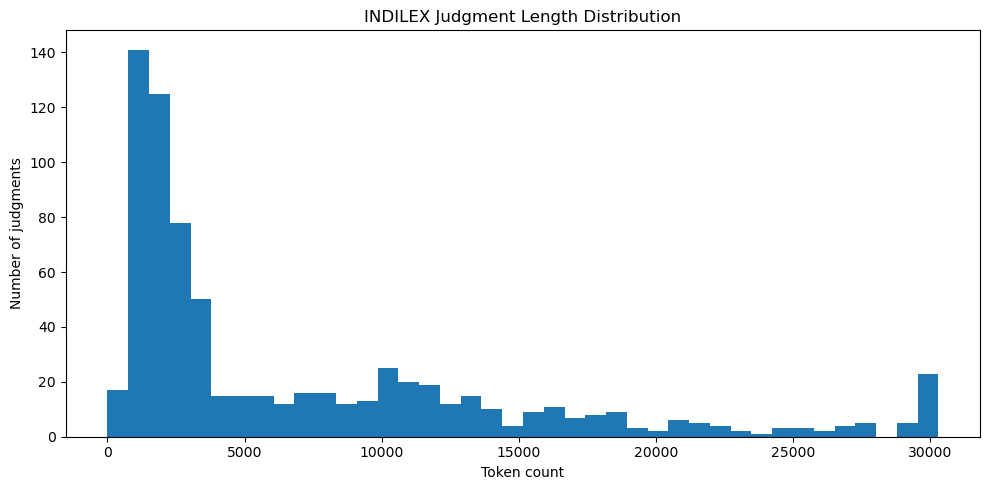

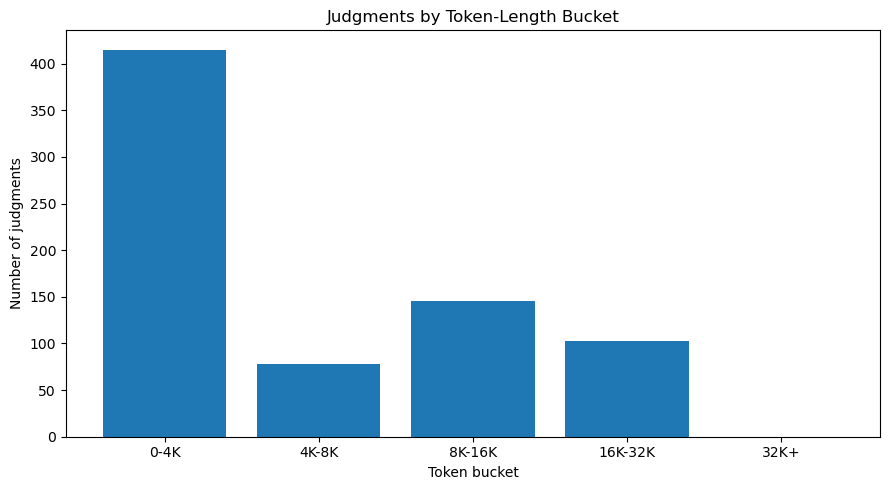

In [18]:
# ============================================================
# VISUALIZATIONS
# ============================================================

metric = "token_count" if USE_TOKENIZER else "char_count"
values = data.loc[data[metric] > 0, metric]

plt.figure(figsize=(10, 5))
plt.hist(values, bins=40)
plt.xlabel("Token count" if USE_TOKENIZER else "Character count")
plt.ylabel("Number of judgments")
plt.title("INDILEX Judgment Length Distribution")
plt.tight_layout()
plt.show()

if USE_TOKENIZER:
    bucket_order = ["0-4K", "4K-8K", "8K-16K", "16K-32K", "32K+"]
    counts = data["length_bucket"].value_counts().reindex(bucket_order, fill_value=0)

    plt.figure(figsize=(9, 5))
    plt.bar(counts.index, counts.values)
    plt.xlabel("Token bucket")
    plt.ylabel("Number of judgments")
    plt.title("Judgments by Token-Length Bucket")
    plt.tight_layout()
    plt.show()


In [19]:
# ============================================================
# SAVE AUDIT REPORTS
# ============================================================

# Keep original dataset untouched. Audit output contains metrics only.
audit_columns = [c for c in [
    "case_id", "language", "case_type",
    "_source_file", "_source_path", "_source_row", "_encoding_used",
    "_is_empty_judgment", "_duplicate_case_id", "_duplicate_judgment",
    "char_count", "word_count", "token_count",
    "length_bucket", "routing_decision", "annotation_state"
] if c in data.columns]

row_audit_path = OUTPUT_DIR / "indilex_row_length_audit.csv"
summary_path = OUTPUT_DIR / "indilex_overall_audit_summary.csv"
per_file_path = OUTPUT_DIR / "indilex_per_file_summary.csv"
missing_path = OUTPUT_DIR / "indilex_annotation_missing_profile.csv"
dup_case_path = OUTPUT_DIR / "indilex_duplicate_case_ids.csv"
dup_text_path = OUTPUT_DIR / "indilex_duplicate_judgments.csv"
load_errors_path = OUTPUT_DIR / "indilex_load_errors.csv"

data[audit_columns].to_csv(row_audit_path, index=False, encoding="utf-8-sig")
summary_df.to_csv(summary_path, index=False, encoding="utf-8-sig")
per_file_summary.to_csv(per_file_path, index=False, encoding="utf-8-sig")
missing_profile_df.to_csv(missing_path, index=False, encoding="utf-8-sig")

duplicate_case_ids[audit_columns].to_csv(dup_case_path, index=False, encoding="utf-8-sig")
duplicate_judgments[audit_columns].to_csv(dup_text_path, index=False, encoding="utf-8-sig")
pd.DataFrame(load_errors).to_csv(load_errors_path, index=False, encoding="utf-8-sig")

if not per_case_summary.empty:
    per_case_summary.to_csv(
        OUTPUT_DIR / "indilex_per_case_type_summary.csv",
        index=False,
        encoding="utf-8-sig"
    )

print("Audit reports saved to:", OUTPUT_DIR)
for p in sorted(OUTPUT_DIR.glob("*.csv")):
    print(" -", p.name)


Audit reports saved to: audit_reports
 - indilex_annotation_missing_profile.csv
 - indilex_duplicate_case_ids.csv
 - indilex_duplicate_judgments.csv
 - indilex_load_errors.csv
 - indilex_overall_audit_summary.csv
 - indilex_per_case_type_summary.csv
 - indilex_per_file_summary.csv
 - indilex_row_length_audit.csv


In [20]:
# ============================================================
# FINAL ROUTING RECOMMENDATION
# ============================================================

print("=" * 70)
print("AUDIT COMPLETE")
print("=" * 70)
print(f"Total rows           : {len(data):,}")
print(f"Empty judgments      : {int(data['_is_empty_judgment'].sum()):,}")
print(f"Duplicate text rows  : {int(data['_duplicate_judgment'].sum()):,}")

if USE_TOKENIZER:
    direct = int((data["routing_decision"] == "direct").sum())
    chunked = int((data["routing_decision"] == "chunk_candidate").sum())
    pct = (100 * chunked / len(data)) if len(data) else 0

    print(f"Direct candidates    : {direct:,}")
    print(f"Chunk candidates     : {chunked:,} ({pct:.2f}%)")
    print(f"Median tokens        : {data['token_count'].median():,.0f}")
    print(f"95th percentile      : {data['token_count'].quantile(0.95):,.0f}")
    print(f"Maximum tokens       : {data['token_count'].max():,.0f}")

    print("\nInterpretation:")
    if pct < 10:
        print("Most judgments fit the direct route. Use adaptive chunking only for the long tail.")
    elif pct < 40:
        print("A mixed direct/chunk routing strategy is appropriate.")
    else:
        print("A substantial part of the dataset exceeds the current safe direct limit; chunking design is important.")
else:
    print("Enable USE_TOKENIZER=True before choosing final chunk sizes.")

print("\nImportant: this notebook does not modify, truncate, summarize, or chunk the original judgments.")


AUDIT COMPLETE
Total rows           : 742
Empty judgments      : 0
Duplicate text rows  : 4
Direct candidates    : 471
Chunk candidates     : 271 (36.52%)
Median tokens        : 3,146
95th percentile      : 25,882
Maximum tokens       : 30,292

Interpretation:
A mixed direct/chunk routing strategy is appropriate.

Important: this notebook does not modify, truncate, summarize, or chunk the original judgments.
